In [1]:
# paso 1 instalar librerias
import pandas as pd
import sys
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# paso 2 verificar la version de python
print("Version de Python: ", sys.version)
print("Version de Pandas: ", pd.__version__)
print("Version de Seaborn: ", sns.__version__)


Version de Python:  3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]
Version de Pandas:  3.0.3
Version de Seaborn:  0.13.2


In [3]:
import os
print("Mi notebook está en:", os.getcwd())
print("Archivos en esta carpeta:", os.listdir('.'))

Mi notebook está en: c:\Users\vaph7\OneDrive\Documentos\Maestria IA\mi_lab_practicas\practicas
Archivos en esta carpeta: ['.venv', 'practica_1', 'practica_1a.ipynb']


In [4]:
# paso 3 cargar el dataset
ds = pd.read_csv(r"C:\Users\vaph7\OneDrive\Documentos\Maestria IA\mi_lab_practicas\datos\dataini.csv")

# Paso 4 mostrar las primeras filas del dataset
print(ds.head())

# paso 5 mostrar la informacion del dataset
print(ds.info())

  ClienteID     Genero  Jubilado Socio Dependientes  Permanencia  \
0   QM-5876   Femenino         0    Si           Si           23   
1   AX-2277   Femenino         0    No           No           32   
2   JT-9442   Femenino         0    No           No           11   
3   PH-0979  Masculino         0    Si           Si           69   
4   SV-3067   Femenino         0    Si           No           68   

  ServicioTelefonico LineasMultiples InternetService      SeguridadOnline  \
0                 Si              No              No  No internet service   
1                 Si              No              No  No internet service   
2                 Si              No              No  No internet service   
3                 Si              Si     Fiber optic                   No   
4                 Si              No             DSL                   Si   

   ... ProteccionDispositivos          TechSupport          StreamingTV  \
0  ...    No internet service  No internet service  N

In [5]:
# paso 6 mostrar valores nulos del dataset
print("Valores nulos por columna:", ds.isnull().sum().sum())
print("Valores nulos por columna:", ds.isnull().sum())

# paso 7 describe dataset
print(ds.describe())
print(ds.describe(include='all'))
print(ds.describe(include='all').T)

Valores nulos por columna: 4
Valores nulos por columna: ClienteID                 0
Genero                    0
Jubilado                  0
Socio                     0
Dependientes              0
Permanencia               0
ServicioTelefonico        0
LineasMultiples           0
InternetService           0
SeguridadOnline           0
RespaldoOnline            0
ProteccionDispositivos    1
TechSupport               0
StreamingTV               2
StreamingMovies           0
Contrato                  0
Facturacion               0
MetodoPago                1
CargoMensual              0
TotalCargos               0
Abandono                  0
dtype: int64
          Jubilado  Permanencia  CargoMensual
count  7048.000000  7048.000000   7048.000000
mean      0.162174    32.381101     64.758258
std       0.368636    24.564197     30.085262
min       0.000000     0.000000     18.250000
25%       0.000000     9.000000     35.500000
50%       0.000000    29.000000     70.350000
75%       0.000000   

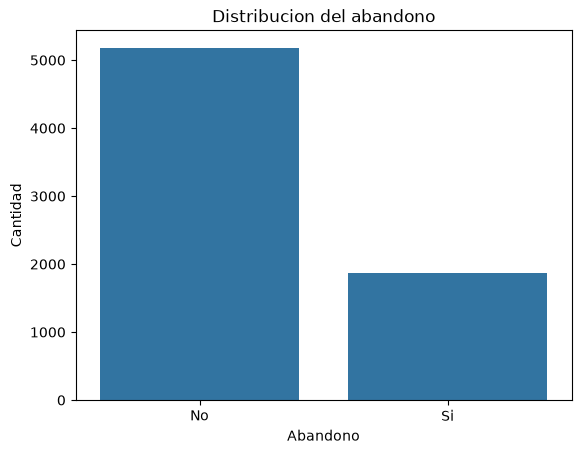

In [6]:
# paso 8 graficcar dataset
sns.countplot(data=ds, x="Abandono")
plt.ylabel("Cantidad")
plt.title("Distribucion del abandono")
plt.show()


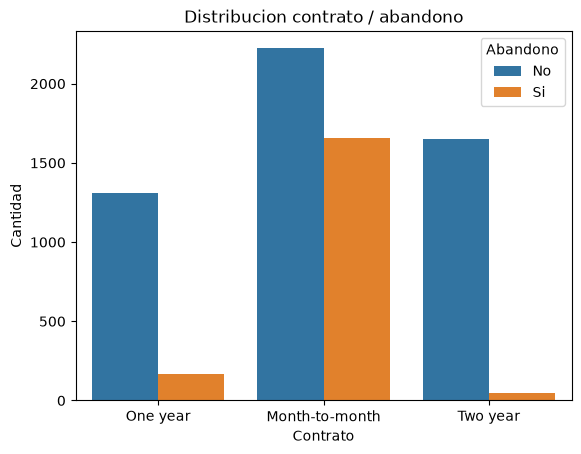

In [7]:
# paso 9 graficoAnalisis por tipo de contrato
sns.countplot(data=ds, x="Contrato", hue="Abandono")
plt.ylabel("Cantidad")
plt.title("Distribucion contrato / abandono")
plt.show()

In [8]:
# paso 10 depuracion de datos
#  1. Aseguramos que ds_nuevo sea una copia limpia e independiente
ds_nuevo = ds.copy()
# 2. Convertimos a texto, eliminamos espacios Y PASAMOS TODO A MAYÚSCULAS
ds_nuevo["ClienteID"] = ds_nuevo["ClienteID"].astype(
    str).str.strip().str.upper()
# 3. Eliminamos duplicados basados en la columna ya homogeneizada
ds_nuevo = ds_nuevo.drop_duplicates(subset=["ClienteID"], keep="first")
# 4. Eliminamos nulos
ds_nuevo = ds_nuevo.dropna()
print(ds_nuevo.describe(include='all').T)
print("Valores nulos por columna:", ds_nuevo.isnull().sum())
# 5. eliminando titulo clienteID
ds_nuevo = ds_nuevo.drop(columns=["ClienteID"])
print(ds_nuevo.describe(include='all').T)

                         count unique             top  freq       mean  \
ClienteID                 7039   7039         QM-5876     1        NaN   
Genero                    7039      2       Masculino  3552        NaN   
Jubilado                7039.0    NaN             NaN   NaN   0.162239   
Socio                     7039      2              No  3639        NaN   
Dependientes              7039      2              No  4931        NaN   
Permanencia             7039.0    NaN             NaN   NaN  32.373775   
ServicioTelefonico        7039      2              Si  6357        NaN   
LineasMultiples           7039      3              No  3388        NaN   
InternetService           7039      3     Fiber optic  3094        NaN   
SeguridadOnline           7039      3              No  3497        NaN   
RespaldoOnline            7039      3              No  3087        NaN   
ProteccionDispositivos    7039      3              No  3094        NaN   
TechSupport               7039      3 

In [9]:
# 11 eliminando titulo clienteID
# ds_nuevo = ds_nuevo.drop(columns=["ClienteID"])
print(ds_nuevo.describe(include='all').T)

                         count unique             top  freq       mean  \
Genero                    7039      2       Masculino  3552        NaN   
Jubilado                7039.0    NaN             NaN   NaN   0.162239   
Socio                     7039      2              No  3639        NaN   
Dependientes              7039      2              No  4931        NaN   
Permanencia             7039.0    NaN             NaN   NaN  32.373775   
ServicioTelefonico        7039      2              Si  6357        NaN   
LineasMultiples           7039      3              No  3388        NaN   
InternetService           7039      3     Fiber optic  3094        NaN   
SeguridadOnline           7039      3              No  3497        NaN   
RespaldoOnline            7039      3              No  3087        NaN   
ProteccionDispositivos    7039      3              No  3094        NaN   
TechSupport               7039      3              No  3472        NaN   
StreamingTV               7039      3 

In [10]:
# paso 12 guardando el dataset depurado

ds_nuevo.to_csv("../datos/ds_depuradoP1.csv, index=False")

In [11]:
# Paso 13 Guardar una copia dataset
ds_prueba = ds_nuevo.copy()

In [ ]:
# Paso adicional Dando un formatoadecuado al Dataset, esta forma no me sirve genera columnas que generan ruido
ds_prueba = pd.get_dummies (ds_nuevo, drop_first=True)
print(ds_prueba)
# solo se  uso de ejemplo de un metodo que no es practico

      Jubilado  Permanencia  CargoMensual  Genero_Masculino  Socio_Si  \
0            0           23         20.05             False      True   
1            0           32         19.75             False     False   
2            0           11         20.05             False     False   
3            0           69         99.45              True      True   
4            0           68         55.90             False      True   
...        ...          ...           ...               ...       ...   
7038         1           42         95.05             False      True   
7039         0           66         90.05             False     False   
7040         1           33        109.90              True      True   
7041         0           34         73.95             False     False   
7042         1           33         54.60              True     False   

      Dependientes_Si  ServicioTelefonico_Si  \
0                True                   True   
1               False      

In [17]:
#Paso 14 preparando la estructura del dataset antes de poner datos, transformer
from sklearn.pipeline import Pipeline
from sklearn.compose import _column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


In [ ]:
# Creando la estructura del dataset
num_cols = ds_nuevo.select.dtites (include = ["int64", "float64"]).columns # error es select.dtypes
cat_cols = ds_nuevo.select_dtypes (include=["object", "category", "bool"]).columns

numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy= "median")),("scaler", StandardScaler())])
categorico_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy= "most_frequent")),("onehot", OneHotEncoder(handle_unknown= "ignore"))])

preprocessor = ColumnTransformer (
    transformers= [
        ("num", numeric_transformer, num_cols),
        ("cat", categorico_transformer, cat_cols)
    ]
)
